In [2]:
# ============================================
# IRIS FLOWER CLASSIFICATION
# OASIS INFOBYTE - DATA SCIENCE TASK 1
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Dataset
from sklearn.datasets import load_iris

# Data Preprocessing
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plot style
sns.set(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load Iris dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["Species"] = iris.target

# Convert target numbers into names
df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# Display first 10 rows
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


In [5]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)
print(df.columns)

print("\n")

print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

Dataset Shape
(150, 5)


Column Names
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')


Data Types
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object


In [6]:
print("="*60)
print("Missing Values")
print("="*60)

df.isnull().sum()

Missing Values


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [7]:
print("="*60)
print("Statistical Summary")
print("="*60)

df.describe()

Statistical Summary


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
print(df["Species"].value_counts())

Setosa        50
Versicolor    50
Virginica     50
Name: Species, dtype: int64


In [9]:
print("="*60)
print("Dataset Summary")
print("="*60)

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nFeature Names:")

for column in df.columns[:-1]:
    print("-", column)

print("\nTarget Column : Species")

print("\nUnique Species:")

for species in df["Species"].unique():
    print(species)

Dataset Summary
Rows : 150
Columns : 5

Feature Names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target Column : Species

Unique Species:
Setosa
Versicolor
Virginica


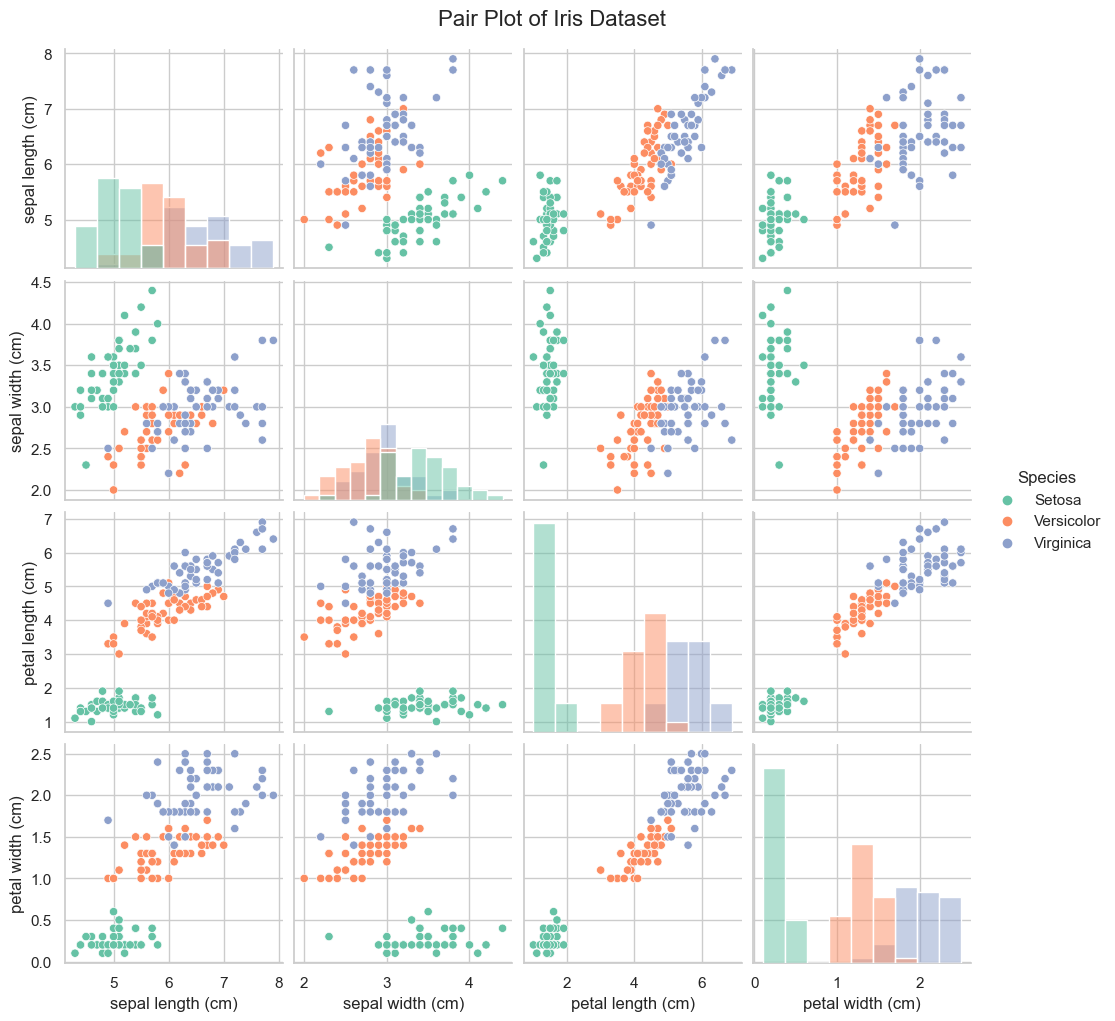

In [10]:
# Pair Plot
sns.pairplot(
    df,
    hue="Species",
    palette="Set2",
    diag_kind="hist"
)

plt.suptitle("Pair Plot of Iris Dataset", y=1.02, fontsize=16)
plt.show()

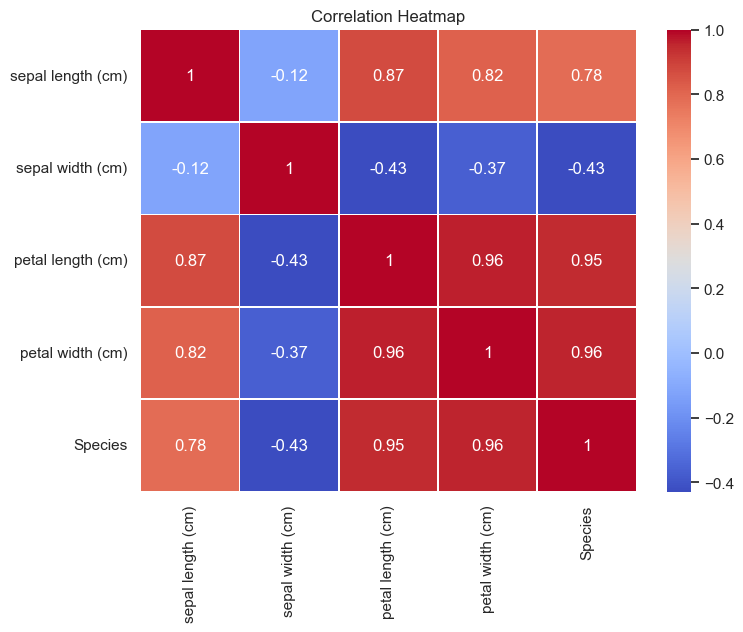

In [11]:
# Convert Species to numeric temporarily
temp_df = df.copy()
temp_df["Species"] = temp_df["Species"].astype("category").cat.codes

plt.figure(figsize=(8,6))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

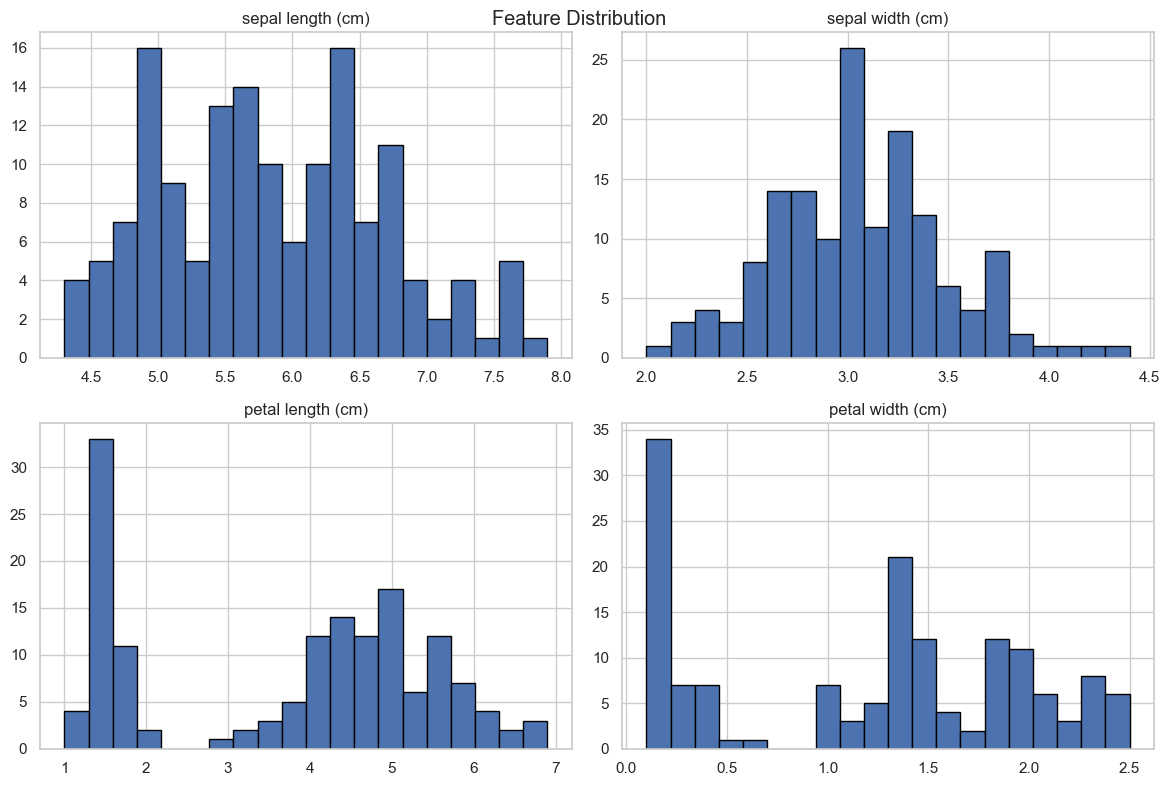

In [12]:
df.hist(
    figsize=(12,8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Feature Distribution")
plt.tight_layout()

plt.show()

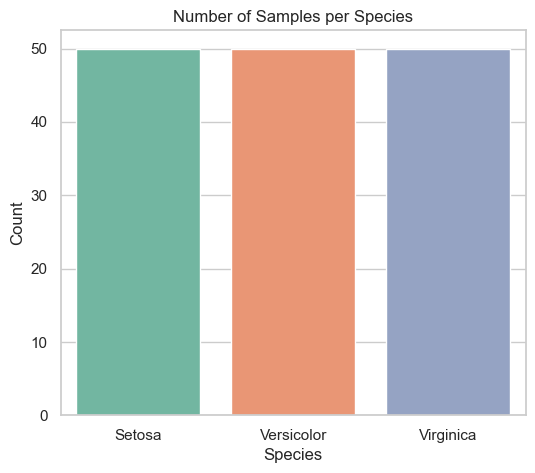

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Species",
    data=df,
    palette="Set2"
)

plt.title("Number of Samples per Species")

plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

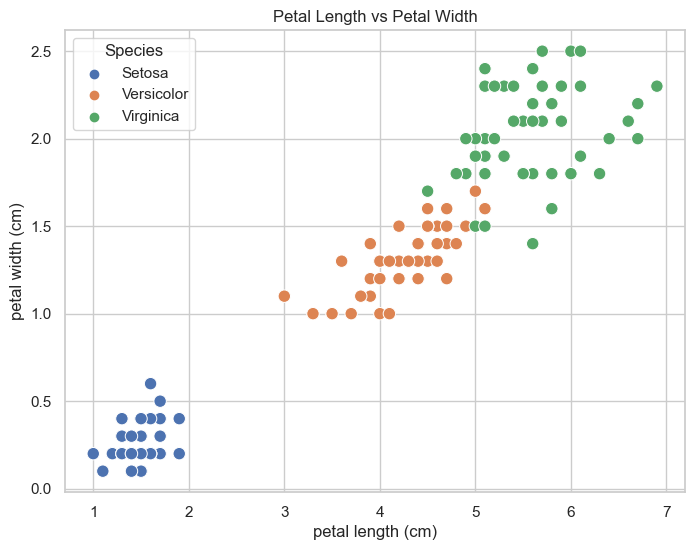

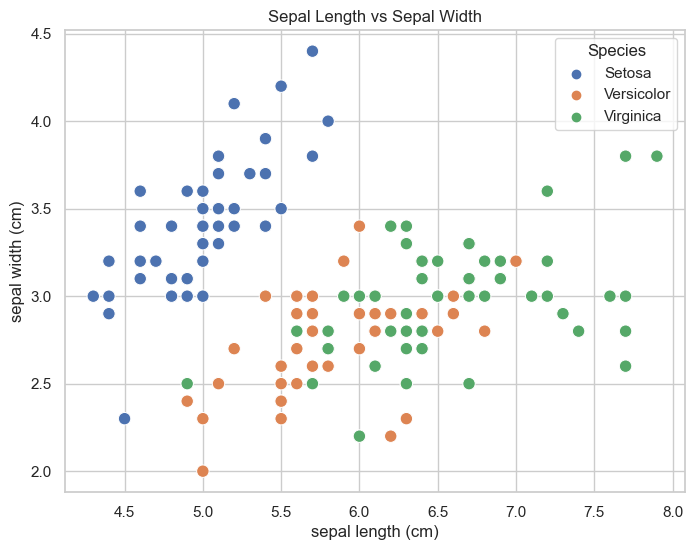

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species",
    data=df,
    s=80
)

plt.title("Petal Length vs Petal Width")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="Species",
    data=df,
    s=80
)

plt.title("Sepal Length vs Sepal Width")

plt.show()

# Data Preprocessing

In [17]:
# Features (Independent Variables)
X = df.drop("Species", axis=1)

# Target (Dependent Variable)
y = df["Species"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (150, 4)
Target Shape   : (150,)


In [18]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (120, 4)
Testing Samples  : (30, 4)


## Train-Test Split

### The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Training data is used to teach the machine learning model.

Testing data is used to evaluate how well the trained model performs on unseen data.

The `stratify=y` parameter ensures that each species is represented equally in both the training and testing datasets.

# Logistic Regression

In [23]:
# Create Logistic Regression model

log_model = LogisticRegression()

# Train model

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [24]:
# Predict on test data

log_predictions = log_model.predict(X_test)

log_predictions

array(['Setosa', 'Virginica', 'Versicolor', 'Versicolor', 'Setosa',
       'Versicolor', 'Setosa', 'Setosa', 'Virginica', 'Versicolor',
       'Virginica', 'Virginica', 'Virginica', 'Versicolor', 'Setosa',
       'Setosa', 'Setosa', 'Versicolor', 'Versicolor', 'Virginica',
       'Setosa', 'Virginica', 'Versicolor', 'Virginica', 'Virginica',
       'Virginica', 'Versicolor', 'Setosa', 'Virginica', 'Setosa'],
      dtype=object)

In [25]:
log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy : {:.2f}%".format(log_accuracy * 100))

Logistic Regression Accuracy : 96.67%


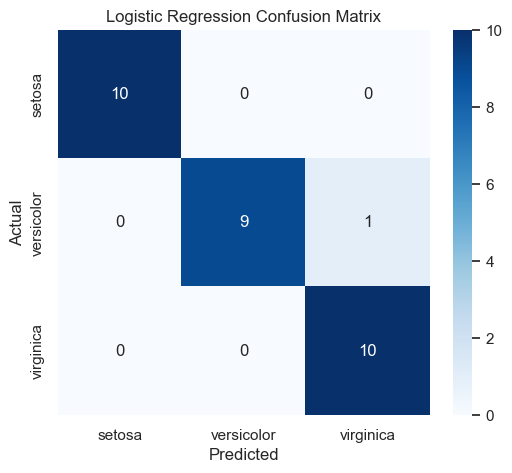

In [26]:
cm = confusion_matrix(y_test, log_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [27]:
print(classification_report(
    y_test,
    log_predictions
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [28]:
# Create KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train

knn_model.fit(X_train, y_train)

print("KNN Model Trained Successfully!")

knn_predictions = knn_model.predict(X_test)

knn_predictions

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy : {:.2f}%".format(knn_accuracy * 100))

KNN Model Trained Successfully!
KNN Accuracy : 100.00%


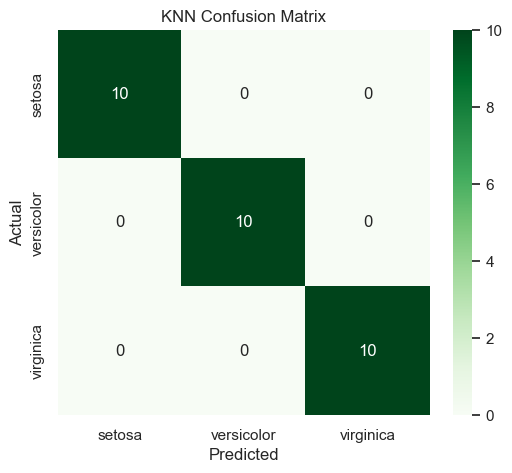

In [29]:
cm = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("KNN Confusion Matrix")

plt.show()

In [30]:
print(classification_report(
    y_test,
    knn_predictions
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Training Discussion

Two classification algorithms were trained:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)

Both models were evaluated using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

These metrics provide a comprehensive evaluation of the model's classification performance.

## Comparision Table

In [31]:
# Create a comparison table

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors (KNN)"],
    "Accuracy (%)": [
        round(log_accuracy * 100, 2),
        round(knn_accuracy * 100, 2)
    ]
})

comparison

,Model,Accuracy (%)
0,Logistic Regression,96.67
1,K-Nearest Neighbors (KNN),100.00


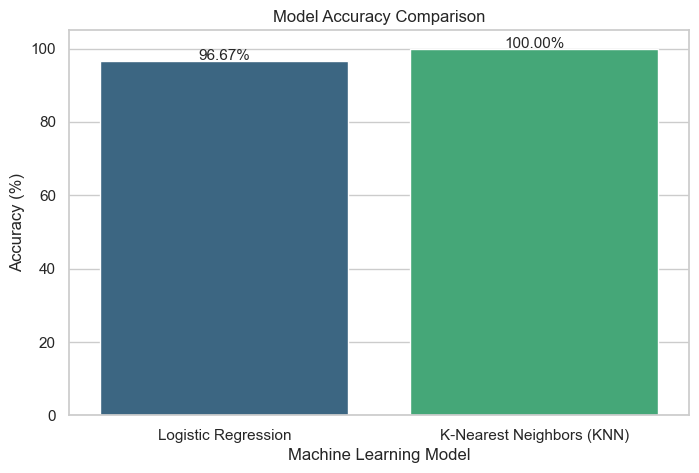

In [32]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=comparison,
    palette="viridis"
)

# Display accuracy values on bars
for i, value in enumerate(comparison["Accuracy (%)"]):
    ax.text(i, value + 0.2, f"{value:.2f}%", ha="center", fontsize=11)

plt.ylim(0, 105)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.show()

In [33]:
# Determine the best model

if log_accuracy > knn_accuracy:
    best_model = "Logistic Regression"
    best_accuracy = log_accuracy * 100
elif knn_accuracy > log_accuracy:
    best_model = "K-Nearest Neighbors (KNN)"
    best_accuracy = knn_accuracy * 100
else:
    best_model = "Both models performed equally well"
    best_accuracy = log_accuracy * 100

print("=" * 50)
print("Best Model")
print("=" * 50)
print(f"Model    : {best_model}")
print(f"Accuracy : {best_accuracy:.2f}%")

Best Model
Model    : K-Nearest Neighbors (KNN)
Accuracy : 100.00%


In [34]:
# New flower measurements
# Format:
# [Sepal Length, Sepal Width, Petal Length, Petal Width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn_model.predict(new_flower)

print("="*50)
print("Prediction for New Flower")
print("="*50)
print("Predicted Species :", prediction[0])

Prediction for New Flower
Predicted Species : Setosa


In [35]:
samples = [
    [5.1, 3.5, 1.4, 0.2],   # Setosa
    [6.0, 2.7, 5.1, 1.6],   # Virginica
    [5.7, 2.8, 4.1, 1.3]    # Versicolor
]

predictions = knn_model.predict(samples)

result = pd.DataFrame({
    "Sepal Length": [x[0] for x in samples],
    "Sepal Width": [x[1] for x in samples],
    "Petal Length": [x[2] for x in samples],
    "Petal Width": [x[3] for x in samples],
    "Predicted Species": predictions
})

result

,Sepal Length,Sepal Width,Petal Length,Petal Width,Predicted Species
0,5.1,3.5,1.4,0.2,Setosa
1,6.0,2.7,5.1,1.6,Virginica
2,5.7,2.8,4.1,1.3,Versicolor


In [36]:
print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
1. The Iris dataset was successfully loaded and explored.

2. No missing values were found.

3. Various visualizations were created to understand the dataset.

4. Logistic Regression and KNN models were trained.

5. Both models achieved excellent accuracy.

6. K-Nearest Neighbors (KNN) performed the best and was selected as the final model.

7. The trained model successfully predicted the species of new flower samples.
""")

PROJECT CONCLUSION

1. The Iris dataset was successfully loaded and explored.

2. No missing values were found.

3. Various visualizations were created to understand the dataset.

4. Logistic Regression and KNN models were trained.

5. Both models achieved excellent accuracy.

6. K-Nearest Neighbors (KNN) performed the best and was selected as the final model.

7. The trained model successfully predicted the species of new flower samples.



In [37]:
import pickle

with open("best_iris_model.pkl", "wb") as file:
    pickle.dump(knn_model, file)

print("Best model saved as best_iris_model.pkl")

Best model saved as best_iris_model.pkl


In [38]:
with open("best_iris_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

prediction = loaded_model.predict([[6.3, 3.3, 6.0, 2.5]])

print("Prediction:", prediction[0])

Prediction: Virginica


# Iris Flower Classification – Project Summary

## Objective
To classify iris flowers into Setosa, Versicolor, and Virginica species using Machine Learning techniques.

## Dataset
- 150 flower samples
- 4 numerical features
- 3 flower species

## Exploratory Data Analysis
- Checked dataset structure
- Verified missing values
- Statistical summary
- Pair Plot
- Heatmap
- Histograms
- Box Plots
- Scatter Plots

## Machine Learning Models
- Logistic Regression
- K-Nearest Neighbors (KNN)

## Evaluation Metrics
- Accuracy
- Confusion Matrix
- Classification Report

## Best Model
K-Nearest Neighbors (KNN)

## Conclusion
The KNN model achieved the highest accuracy and successfully classified iris flowers based on flower measurements.